# AirPassengers Forecasting with a Custom LSTM

This notebook uses the handmade `lstm/` implementation to train a one-step regression model on the AirPassengers dataset.

It covers:
- data loading and visualization
- time series sequence preparation
- model training and evaluation
- aligned test predictions
- a recursive 24-month forecast


In [1]:
import os
import sys
import csv
from datetime import datetime
import pickle
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

from lstm.lstm_layer import LSTMLayer
from lstm.dense_layer import DenseLayer
from lstm.network import LSTMNetwork
from lstm.optimizers import Adam

seq_len = 12
batch_size = 16


def prepare_data(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i:i + seq_len])
        y.append(series[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def add_months(date, n):
    year = date.year + (date.month - 1 + n) // 12
    month = ((date.month - 1 + n) % 12) + 1
    return datetime(year, month, 1)


def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


In [2]:
# This cell is intentionally blank because imports and helpers are defined above.

## Load the AirPassengers dataset

In [3]:
data_path = os.path.join(PROJECT_ROOT, 'data', 'AirPassengers.csv')

months = []
values = []
with open(data_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        months.append(datetime.strptime(row[0], '%Y-%m'))
        values.append(float(row[1]))

values = np.array(values, dtype=np.float32)

print('Rows:', len(values))
print('Date range:', months[0].strftime('%Y-%m'), 'to', months[-1].strftime('%Y-%m'))
print('Min passengers:', values.min())
print('Max passengers:', values.max())
print('Mean passengers:', round(values.mean(), 2))


Rows: 144
Date range: 1949-01 to 1960-12
Min passengers: 104.0
Max passengers: 622.0
Mean passengers: 280.3


## AirPassengers monthly series

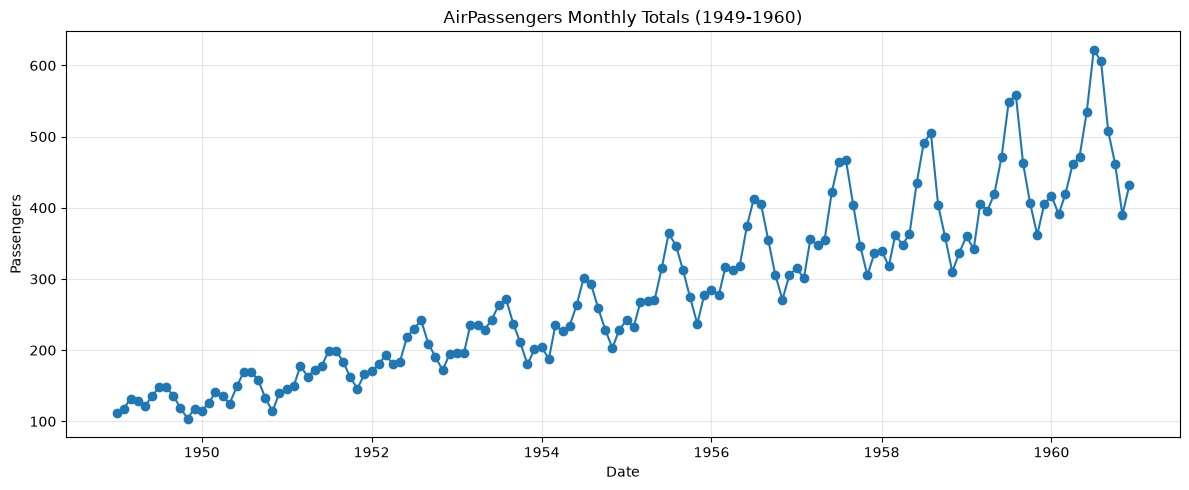

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(months, values, marker='o', linewidth=1.5)
plt.title('AirPassengers Monthly Totals (1949-1960)')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Review the dataset and model structure before training

## Prepare the time series dataset for one-step forecasting

In [5]:
print('Building dataset with', seq_len, 'lagged months')

X, y = prepare_data(values, seq_len)
X = X.reshape(X.shape[0], seq_len, 1)

train_end = int(len(X) * 0.70)
val_end = train_end + int(len(X) * 0.15)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

test_months = months[val_end + seq_len:]

print('Total samples:', len(X))
print('Train samples:', X_train.shape[0])
print('Validation samples:', X_val.shape[0])
print('Test samples:', X_test.shape[0])

model_path = os.path.join(PROJECT_ROOT, 'lstm_model.pkl')
if not os.path.exists(model_path):
    raise FileNotFoundError(f'Expected saved model at {model_path}. Run train.py first to create lstm_model.pkl.')

with open(model_path, 'rb') as f:
    model_data = pickle.load(f)

scaler = model_data.get('scaler')
if scaler is None:
    raise ValueError('Saved model does not contain scaler metadata. Re-run train.py with AirPassengers dataset mode.')

normalize = lambda x: (x - scaler['mean']) / scaler['std']
denormalize = lambda x: x * scaler['std'] + scaler['mean']

X_train_norm = normalize(X_train)
X_val_norm = normalize(X_val)
X_test_norm = normalize(X_test)

y_train_norm = normalize(y_train.reshape(-1, 1)).reshape(-1)
y_val_norm = normalize(y_val.reshape(-1, 1)).reshape(-1)
y_test_norm = normalize(y_test.reshape(-1, 1)).reshape(-1)

print(f'Training scale mean={scaler["mean"]:.2f}, std={scaler["std"]:.2f}')


Building dataset with 12 lagged months
Total samples: 132
Train samples: 92
Validation samples: 19
Test samples: 21
Training scale mean=222.74, std=72.90


## Load the trained LSTM model weights

This notebook now loads the saved model parameters and scaler from `lstm_model.pkl` instead of training locally.

In [6]:
hidden_size = model_data.get('hidden_size', 64)
output_size = model_data.get('output_size', 1)

model = LSTMNetwork()
model.add_lstm_layer(LSTMLayer(input_size=1, hidden_size=hidden_size))
model.add_dense_layer(DenseLayer(input_size=hidden_size, output_size=output_size, activation_fn=None, activation_derivative=None))

model.set_optimizer(Adam(learning_rate=model_data.get('lr', 0.001)))
model.set_weights(model_data['weights'])

print(f'Loaded model from {model_path}')
print(f'Hidden size: {hidden_size}, output size: {output_size}')
print(f'Training epochs in saved model: {len(model_data.get("train_losses", []))}')


Loaded model from /home/manu/Desktop/Staff/Data Science/ML/LSTM/lstm_model.pkl
Hidden size: 64, output size: 1
Training epochs in saved model: 50


## Build and train the custom LSTM regression model

In [7]:
# Using the pretrained model weights loaded from train.py

train_history = model_data.get('train_losses', [])
val_history = model_data.get('val_losses', [])
test_history = model_data.get('test_losses', [])

print(f'Loaded trained model weights and history from {model_path}')
print(f'Train loss points: {len(train_history)}')
print(f'Validation loss points: {len(val_history)}')
print(f'Test loss points: {len(test_history)}')


Loaded trained model weights and history from /home/manu/Desktop/Staff/Data Science/ML/LSTM/lstm_model.pkl
Train loss points: 50
Validation loss points: 50
Test loss points: 50


## Training and validation history

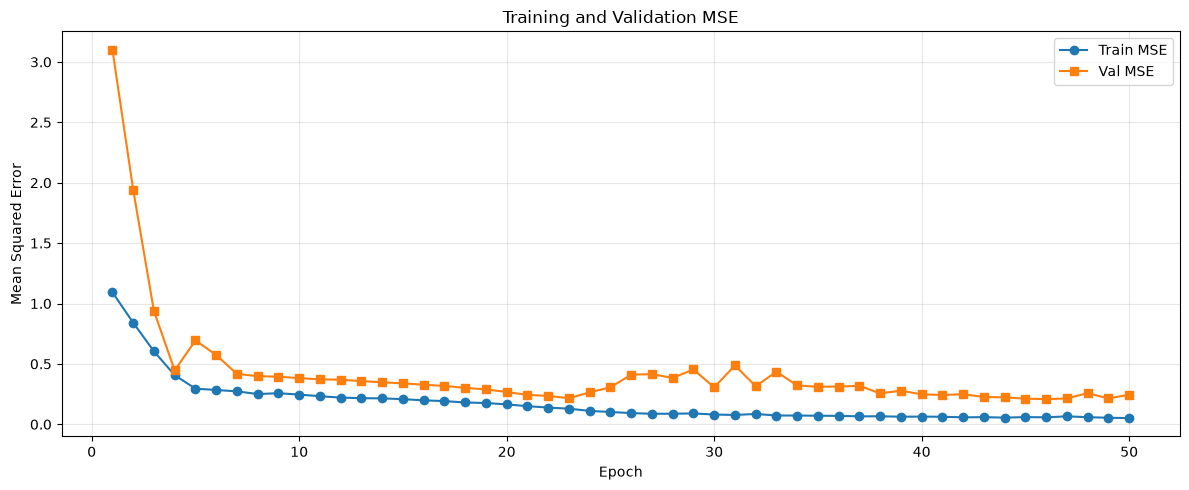

Final Train MSE: 0.0515
Final Val MSE:   0.2451


In [8]:
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(train_history) + 1), train_history, label='Train MSE', marker='o')
plt.plot(range(1, len(val_history) + 1), val_history, label='Val MSE', marker='s')
plt.title('Training and Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if train_history:
    print(f'Final Train MSE: {train_history[-1]:.4f}')
if val_history:
    print(f'Final Val MSE:   {val_history[-1]:.4f}')


## Test set evaluation

Test MSE: 3255.9113


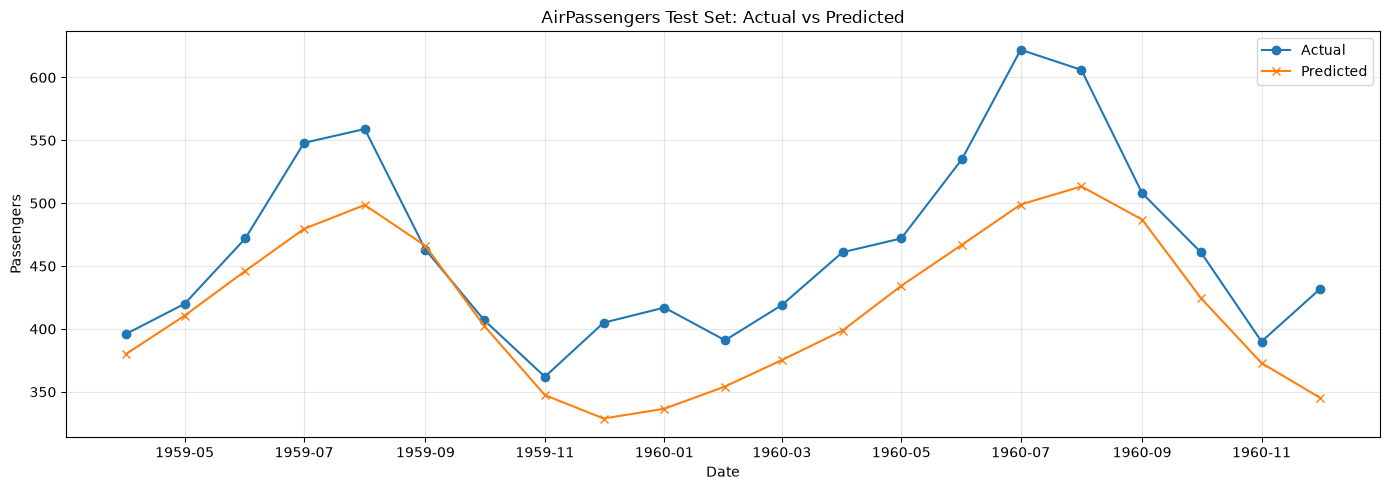

In [9]:
test_pred_scaled = model.predict(X_test_norm).reshape(-1)
test_pred = denormalize(test_pred_scaled)

test_mse = np.mean((test_pred - y_test) ** 2)
print(f'Test MSE: {test_mse:.4f}')

plt.figure(figsize=(14, 5))
plt.plot(test_months, y_test, label='Actual', marker='o')
plt.plot(test_months, test_pred, label='Predicted', marker='x')
plt.title('AirPassengers Test Set: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 24-month recursive forecast

In [10]:
future_steps = 24
# Start recursive forecasting from the last observed actual values,
# not from the final test input window used for evaluating the model.
current_window = normalize(values[-seq_len:]).reshape(seq_len, 1).copy()
forecast_scaled = []

for _ in range(future_steps):
    pred_output = model.predict(current_window.reshape(1, seq_len, 1))
    prediction_scaled = pred_output[0, 0]
    forecast_scaled.append(prediction_scaled)
    current_window = np.concatenate([current_window[1:], [[prediction_scaled]]], axis=0)

forecast_scaled = np.array(forecast_scaled)
forecast_values = denormalize(forecast_scaled)

print('Generated', future_steps, 'forecast months after', months[-1].strftime('%Y-%m'))


Generated 24 forecast months after 1960-12


## Forecast plotting

Plot the recursive 24-month forecast produced from the last test window and compare it with the historical AirPassengers data.

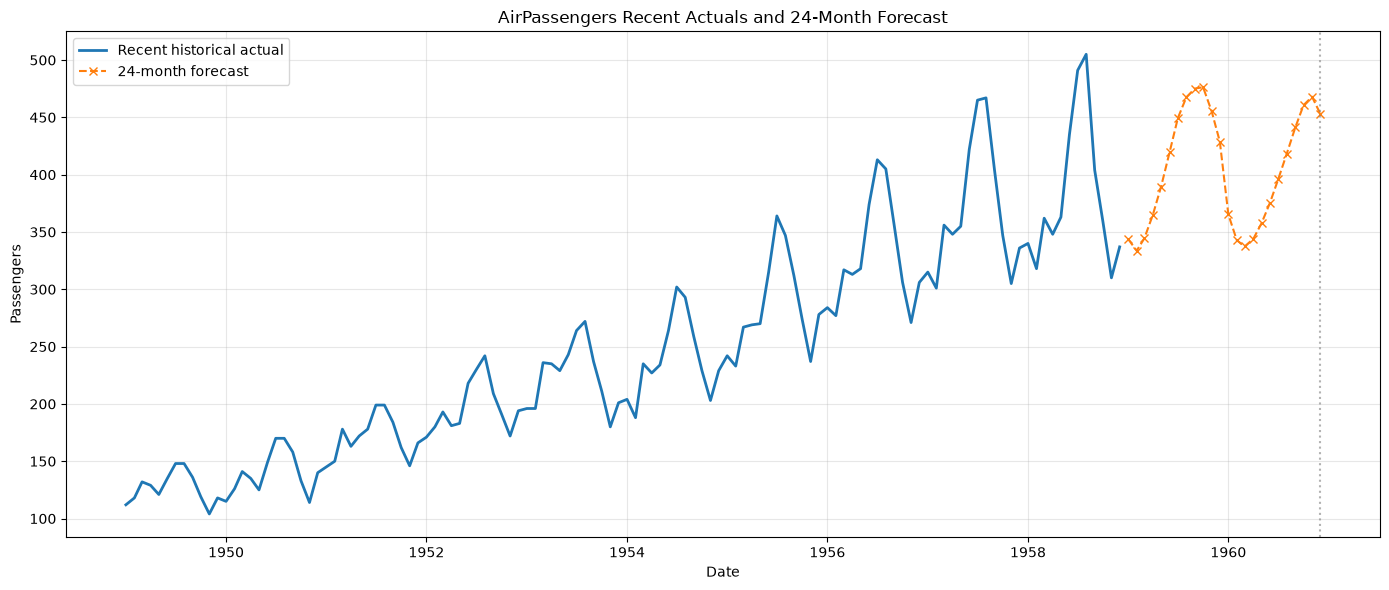

In [11]:
recent_history = 24
plot_values = values[:-recent_history]
plot_months = months[:-recent_history]

future_dates = [add_months(plot_months[-1], i + 1) for i in range(future_steps)]

plt.figure(figsize=(14, 6))
plt.plot(plot_months, plot_values, label='Recent historical actual', linewidth=2)
plt.plot(future_dates, forecast_values, label='24-month forecast', linestyle='--', marker='x')
plt.axvline(months[-1], color='gray', linestyle=':', alpha=0.6)
plt.title('AirPassengers Recent Actuals and 24-Month Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
print('Forecast start:', future_dates[0].strftime('%Y-%m'))
print('Forecast end:', future_dates[-1].strftime('%Y-%m'))
print('First forecast values:', np.round(forecast_values[:3], 1).tolist())
print('Last forecast values:', np.round(forecast_values[-3:], 1).tolist())


Forecast start: 1959-01
Forecast end: 1960-12
First forecast values: [343.8, 333.6, 344.5]
Last forecast values: [460.7, 468.0, 453.2]


In [13]:
# Notebook complete. Run the cells in order for data loading, training, evaluation, and forecasting.